# Machine Learning Project for California Housing 
Based on _Hands-on Machine Learning_ by Aurelien Geron


In [1]:
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load Data

In [2]:
housing_full = pd.read_csv(Path("data/housing.csv"))

## Visualise Data

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

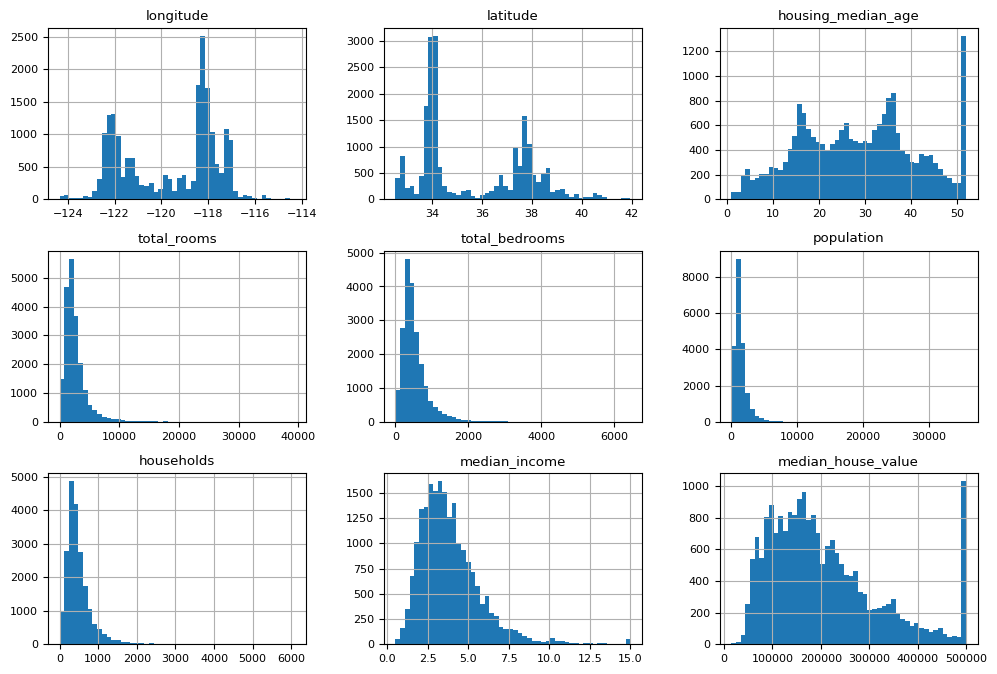

In [3]:
plt.rc("font", size=8)
housing_full.hist(bins=50, figsize=(12, 8))

Observations: 
- median age and median income are capped. This may be wrongly learnt by the model
- many features are right-skewed, which is not good for machine learning
- total_bedrooms have null values 
- different features have very different scales

## Train Test Split
- you can pass it multiple datasets with an identical number of rows, and it will split them on the same indices
- splitting randomly here is fine, but it may not be when population size is small
- here we are creating a new feature `income_cat` for use in stratified sampling

In [4]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"], 
                                    bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf],
                                    labels=[1, 2, 3, 4, 5])


Visualisation of income_cat

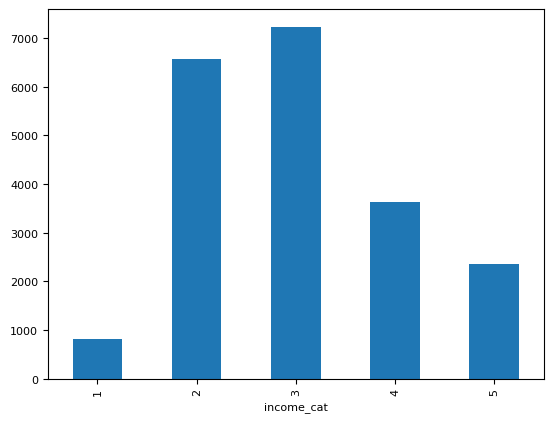

In [5]:
housing_full["income_cat"].value_counts().sort_index().plot(kind="bar")
plt.show()

Comparing stratified sampling and random sampling
- apparently the composition of test_1 is closer to housing_full

In [6]:
# splitting randomly 
train, test = train_test_split(housing_full, test_size=0.2, random_state=42)

# splitting with stratified sampling 
train_1, test_1 = train_test_split(housing_full, test_size=0.2, random_state=42, stratify=housing_full["income_cat"])

# print(test["income_cat"].value_counts().sort_index() / len(test))
# print(test_1["income_cat"].value_counts().sort_index() / len(test))
# print(housing_full["income_cat"].value_counts().sort_index() / len(housing_full))

# now income_cat is useless, we drop it 
for set in (train_1, test_1): 
    set.drop("income_cat", axis=1, inplace=True)

# make a copy of train_1 for future use 
housing: pd.DataFrame = train_1.copy()

## Data Visualisation
Visualise geographical data

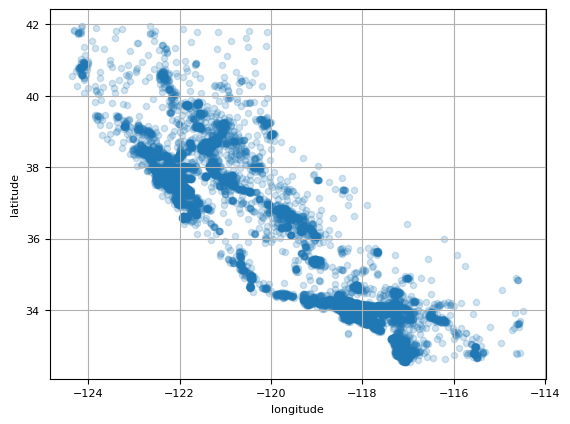

In [7]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()


Check correlations
- median house value is not correlated to population. Why? 

In [8]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

Create scatter matrix

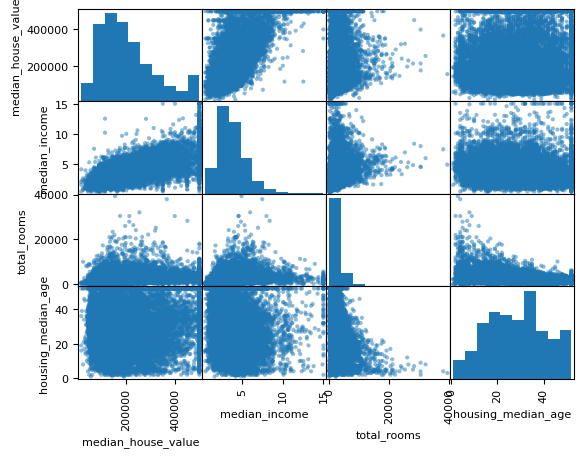

In [9]:
from pandas.plotting import scatter_matrix
useful_attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[useful_attributes])
plt.show()

Plot a scatter of median house value and median income

<Axes: xlabel='median_income', ylabel='median_house_value'>

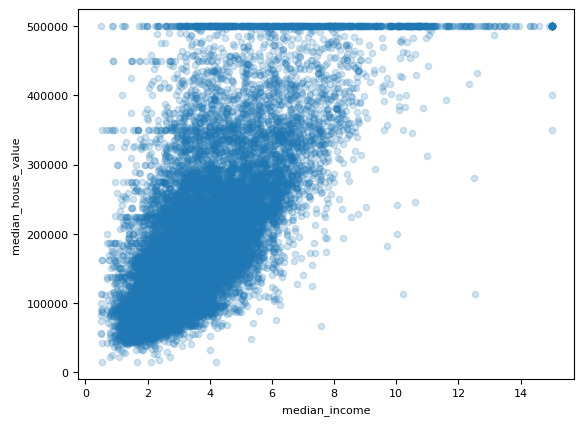

In [10]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.2)

## Combine Attributes
- more rooms per house >> higher value
- a larger percentage of rooms are bedrooms >> lower value

In [11]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

useful_attributes_1 = ["rooms_per_house", "bedrooms_ratio", "people_per_house", "median_house_value"]
new_corr_matrix = housing[useful_attributes_1].corr()
print(new_corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value    1.000000
rooms_per_house       0.143663
people_per_house     -0.038224
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64


## Prepare the data
- write functions instead of doing it manually
- so that the transformation is easily reproducible

In [12]:
# start with a clean set of training data
housing = train_1.drop("median_house_value", axis=1)
housing_y = train_1["median_house_value"].copy()

Fill in missing total_bedrooms data
- Can use .fillna(), but better to use SimpleImputer
- It stores median value, which can be used on not only the training set

In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# median can only be computed for numerical values
# so we drop ocean_proximity
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)
X = imputer.transform(housing_num)

# X is a numpy array, not a pandas dataframe 
housing_tr = pd.DataFrame(X, columns=housing_num.columns, 
                          index=housing_num.index)
housing_tr.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


Convert categorical attributes into numbers

In [14]:
ocean_prox = housing[["ocean_proximity"]].copy()

from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
ocean_prox_ordinal = ordinal_encoder.fit_transform(ocean_prox)

# the problem with ordinal encoder is, the model will assume that 
# closer values are more similar, but that is not the case here
# so we use one hot encoder
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder()
ocean_prox_onehot = onehot_encoder.fit_transform(ocean_prox)
ocean_prox_df = pd.DataFrame(ocean_prox_onehot.toarray(), columns=onehot_encoder.get_feature_names_out(), index=housing.index)


In [15]:
housing.sort_values("median_income", ascending=False).head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
613,-118.33,34.06,52.0,1841.0,240.0,693.0,218.0,15.0001,<1H OCEAN
549,-118.33,34.07,52.0,1482.0,171.0,531.0,161.0,15.0001,<1H OCEAN
9701,-118.10,34.13,47.0,2234.0,276.0,749.0,260.0,15.0001,<1H OCEAN
17773,-118.40,34.08,52.0,3815.0,439.0,1266.0,413.0,15.0001,<1H OCEAN
13076,-121.96,37.74,2.0,200.0,20.0,25.0,9.0,15.0001,<1H OCEAN


Feature Scaling
- Total number of rooms ranges from 2 to 39320
- Median income ranges from 0.49 to 15.1
- Without feature scaling, the model will prioritise total number of rooms 

**WARNING:**
- ONLY fit on training data. DO NOT fit on validation or test data. 

In [16]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler().set_output(transform="pandas")
housing_tr_scaled = std_scaler.fit_transform(housing_tr)

Notice that population is skewed to the right (i.e. have a long right tail)  
We want to make it symmetrical
- take square root
- or take logarithm

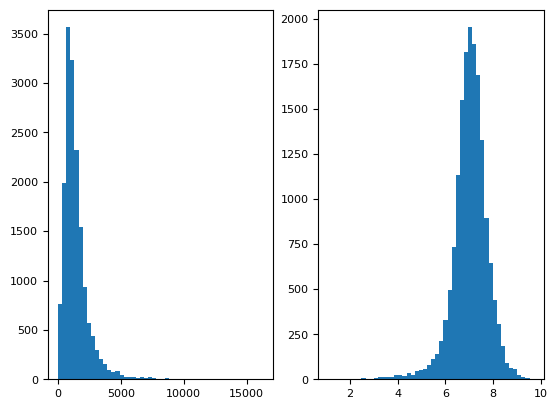

In [17]:
fig, axes = plt.subplots(1, 2)
axes[0].hist(housing["population"], bins=50)
axes[1].hist(np.log(housing["population"]), bins=50)
plt.show()

If you have a multi-modal distribution (multiple peaks)
- housing median age has two peaks, one at 16 and another at 35
- Can split the data into bins and treat the feature as a categorical data
    - e.g. split housing median age into new, middle, old
- Or use RBF to measure the similarity between all values and a fixed point (the peak)


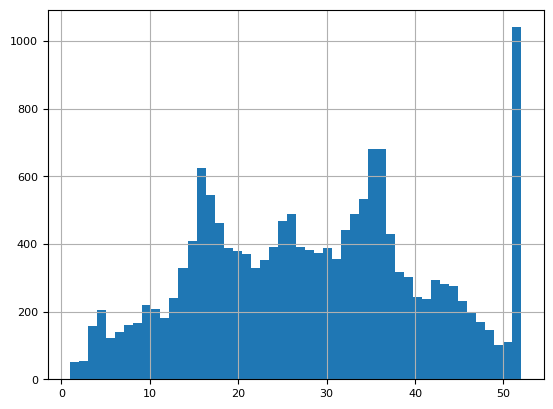

In [18]:
from sklearn.metrics.pairwise import rbf_kernel

housing["housing_median_age"].hist(bins=50)
age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], 0.1)

TransformedTargetRegressor  

Sometimes the labels (y) also need to be transformed. After you obtain predictions,  
you need to revert the transformed predictions back. 

I can also define my own transformer, such as a log transformer

In [19]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

## Transformation Pipeline

In [20]:
from sklearn.pipeline import Pipeline 

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("standardise", StandardScaler()), 
])
num_pipeline.set_output(transform="pandas")
housing_num_prepared = num_pipeline.fit_transform(housing_num)


Make one pipeline that handles both categorical and numerical attributes

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
"total_bedrooms", "population", "households", "median_income"]

cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

### Put everything in one pipeline

Create a FunctionTransformer that computes new features like rooms_per_house and bedroom_ratio

In [22]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]
def ratio_name(function_transformer, feature_names_in):
    return ["ratio"] # feature names out
def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

Log transformer

In [23]:
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"), 
    StandardScaler())

Cluster Similarity
- Measure how close one sample (row) is to the centre of a cluster

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

Final pipeline

In [25]:
from sklearn.compose import make_column_selector

cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"), 
                                     StandardScaler())   

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
    "households", "median_income"]),
    ("geo", cluster_simil, ["latitude", "longitude"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
],
remainder=default_num_pipeline) # one column remaining: housing_median_age

In [26]:
housing_prepared = preprocessing.fit_transform(housing)
# preprocessing.get_feature_names_out()

c:\Users\cheng\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\cheng\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\cheng\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\cheng\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\cheng\AppData\L

## Select and train the model

### Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression

lin_pipeline = make_pipeline(preprocessing, LinearRegression())
lin_pipeline.fit(housing, housing_y)
housing_predictions = lin_pipeline.predict(housing)
print(housing_predictions[:5].round(-2))
housing_y.iloc[:5]

[246000. 372700. 135700.  91400. 330900.]


13096    458300.0
14973    483800.0
3785     101700.0
14689     96100.0
20507    361800.0
Name: median_house_value, dtype: float64

Measure performance with using test labels 

In [28]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_y, housing_predictions)
print("Linear regression rmse = ", lin_rmse.round(2))
print(housing_y.mean())
print("Percentage error = ", (lin_rmse / housing_y.mean()).round(2))


Linear regression rmse =  68972.89
206333.51865310076
Percentage error =  0.33


### Decision tree regressor

In [29]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_y)
tree_predictions = tree_reg.predict(housing)

tree_error = root_mean_squared_error(housing_y, tree_predictions)
tree_error


np.float64(0.0)

### Cross validation on decision tree

In [30]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_y, scoring="neg_root_mean_squared_error", cv=10)

In [31]:
(67013-68972) / 68972

-0.028402830133967407

### Random forest regressor

In [32]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_reg.fit(housing, housing_y)
forest_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_y, forest_predictions)
print(forest_rmse) 

# forest_rmse = 17519.685029292894


17519.685029292894


### Cross validation on random forest

In [33]:
# 3-fold cross validation
forest_rmses = -cross_val_score(forest_reg, housing, housing_y, scoring="neg_root_mean_squared_error", cv=3)

In [34]:
print(forest_rmses.mean().round())

47975.0


## Hyperparameters tuning

### Randomized search

Tune the random forest inside a pipeline so that each cross-validation fold fits preprocessing only on that fold's training data. The fitted `search.best_estimator_` then contains both the learned preprocessing and the tuned random forest.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = make_pipeline(
    preprocessing,
    RandomForestRegressor(
        random_state=42,
        n_jobs=1 # number of CPU cores to use
    )
)

params = {
    "randomforestregressor__n_estimators": [200, 500, 800, 1200],
    "randomforestregressor__max_depth": [None, 5, 10, 20, 30],
    "randomforestregressor__min_samples_split": [2, 5, 10, 20],
    "randomforestregressor__min_samples_leaf": [1, 2, 4, 8],
    "randomforestregressor__max_features": [1.0, "sqrt", 0.3, 0.5, 0.7],
    "randomforestregressor__bootstrap": [True, False]
}

search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=params,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1, # use all CPU cores; let the search handle parallelism
    random_state=42
)

search.fit(housing, housing_y)

In [ ]:
import joblib

best_estimator = search.best_estimator_
model_path = Path("data/model/random_forest.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_estimator, model_path)
print(f"Saved model to {model_path}")

# pd.DataFrame(search.cv_results_)
# best_rmses = -cross_val_score(best_estimator, housing, housing_y, scoring="neg_root_mean_squared_error", cv=3)

## Test Set Performance

### Random forest

`best_estimator` is a complete pipeline containing both preprocessing and the tuned random forest. Calling `predict(test_X)` automatically transforms the test data using the preprocessing parameters learned from the training set, then passes the transformed features to the random forest.

In [ ]:
test_X = test_1.drop("median_house_value", axis=1)
test_y = test_1["median_house_value"].copy()

test_predictions = best_estimator.predict(test_X)

test_rmse = root_mean_squared_error(test_y, test_predictions)
print("Test rmse =", test_rmse.round())

# Test rmse = 44479


### Linear regression

In [ ]:
test_X = test_1.drop("median_house_value", axis=1)
lin_test_predictions = lin_pipeline.predict(test_X)
lin_test_rmse = root_mean_squared_error(test_y, lin_test_predictions)
print("Linear regression test rmse =", lin_test_rmse.round())

# Linear regression test rmse = 76081

Linear regression test rmse = 76081.0
